Dataset shape: (5000, 10)

First 5 rows:
        City  Age  Monthly_Income Education_Level Employment_Type  \
0    Lucknow   64          124641       Secondary      Unemployed   
1  Hyderabad   63          137267    Postgraduate         Private   
2     Jaipur   69           58517       Secondary      Government   
3    Chennai   36           39012       Secondary         Private   
4    Lucknow   30          147487       Secondary      Government   

   Digital_Usage_Hours  Household_Size   Area_Type  Govt_Scheme_Usage  \
0                 9.10               2       Urban                  1   
1                 5.68               1       Rural                  4   
2                 9.28               7       Rural                  3   
3                 5.94               4  Semi-Urban                  4   
4                 1.16               1       Urban                  0   

   Citizen_Segment  
0                1  
1                1  
2                1  
3                0  


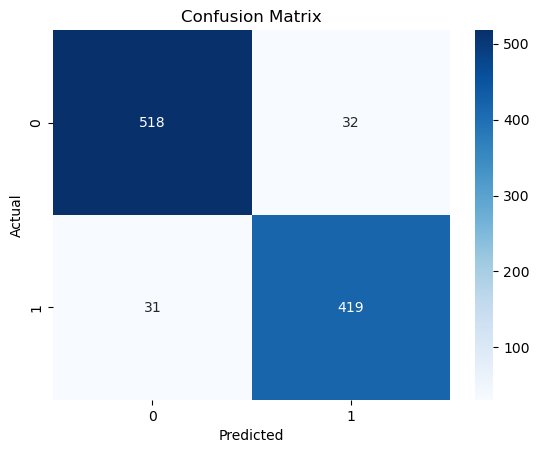


Feature Importance:
               feature  importance
5  Digital_Usage_Hours    0.384808
2       Monthly_Income    0.166861
3      Education_Level    0.162003
4      Employment_Type    0.103314
8    Govt_Scheme_Usage    0.048641
1                  Age    0.047473
0                 City    0.031112
7            Area_Type    0.030105
6       Household_Size    0.025683

✅ Model saved as 'citizen_segment_model.pkl'
✅ Label encoders saved as 'label_encoders.pkl'


In [4]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load the data (assuming the file is saved as 'citizen.xls')
# Since it's actually CSV-like content, we'll load it from the copied text
# But here I'll simulate loading from the file you provided
df = pd.read_csv('citizen.csv')  # or use pd.read_csv if it's CSV

# Display basic info
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing values:\n", df.isnull().sum())

# Encode categorical features
categorical_cols = ['City', 'Education_Level', 'Employment_Type', 'Area_Type']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features and target
X = df.drop('Citizen_Segment', axis=1)
y = df['Citizen_Segment']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# ============================================
# SAVE MODEL FOR BACKEND
# ============================================
joblib.dump(rf, 'citizen_segment_model.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')

print("\n✅ Model saved as 'citizen_segment_model.pkl'")
print("✅ Label encoders saved as 'label_encoders.pkl'")